<a href="https://colab.research.google.com/github/mathumitha-27-cs/ML_1/blob/main/uber.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv('/content/uber.csv')

In [3]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1.0
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1.0
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1.0
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3.0
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80416 entries, 0 to 80415
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         80416 non-null  int64  
 1   key                80416 non-null  object 
 2   fare_amount        80416 non-null  float64
 3   pickup_datetime    80416 non-null  object 
 4   pickup_longitude   80416 non-null  float64
 5   pickup_latitude    80416 non-null  float64
 6   dropoff_longitude  80416 non-null  float64
 7   dropoff_latitude   80415 non-null  float64
 8   passenger_count    80415 non-null  float64
dtypes: float64(6), int64(1), object(2)
memory usage: 5.5+ MB


In [5]:
df.shape

(80416, 9)

In [6]:
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,8.041600e+04,80416.000000,80416.000000,80416.000000,80416.000000,80415.000000,80415.000000
mean,2.769164e+07,11.381542,-72.533096,39.945845,-72.567713,39.934459,1.674874
std,1.601885e+07,9.924870,11.857315,8.557173,15.738776,6.803074,1.295577
min,4.800000e+01,-5.000000,-1340.648410,-74.015515,-3356.666300,-74.009465,0.000000
25%,1.380297e+07,6.000000,-73.992020,40.734812,-73.991417,40.733664,1.000000
50%,2.767201e+07,8.500000,-73.981775,40.752595,-73.980082,40.752982,1.000000
75%,4.150601e+07,12.500000,-73.967171,40.767118,-73.963773,40.768112,2.000000
max,5.542169e+07,350.000000,40.808425,1644.421482,40.828672,872.697628,6.000000


In [7]:
list(df)

['Unnamed: 0',
 'key',
 'fare_amount',
 'pickup_datetime',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'passenger_count']

In [8]:
df.drop(['Unnamed: 0','key'],axis=1,inplace=True)

In [9]:
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1.0
1,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1.0
2,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1.0
3,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3.0
4,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5.0


In [10]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [11]:
df.isnull().sum()

,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,1
passenger_count,1


In [12]:
df.dropna(inplace=True)

In [13]:

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 80415 entries, 0 to 80414
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   fare_amount        80415 non-null  float64            
 1   pickup_datetime    80415 non-null  datetime64[ns, UTC]
 2   pickup_longitude   80415 non-null  float64            
 3   pickup_latitude    80415 non-null  float64            
 4   dropoff_longitude  80415 non-null  float64            
 5   dropoff_latitude   80415 non-null  float64            
 6   passenger_count    80415 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(6)
memory usage: 4.9 MB


In [14]:
df['year'] = df['pickup_datetime'].dt.year
df['month'] = df['pickup_datetime'].dt.month
df['day'] = df['pickup_datetime'].dt.day
df['hour'] = df['pickup_datetime'].dt.hour
df['weekday'] = df['pickup_datetime'].dt.weekday

In [15]:
df.drop('pickup_datetime', axis=1, inplace=True)

<Axes: xlabel='hour', ylabel='count'>

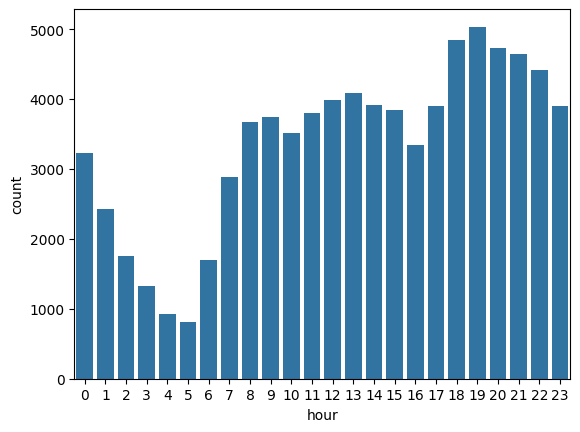

In [50]:
sns.countplot( x='hour',data=df)

<Axes: xlabel='hour', ylabel='fare_amount'>

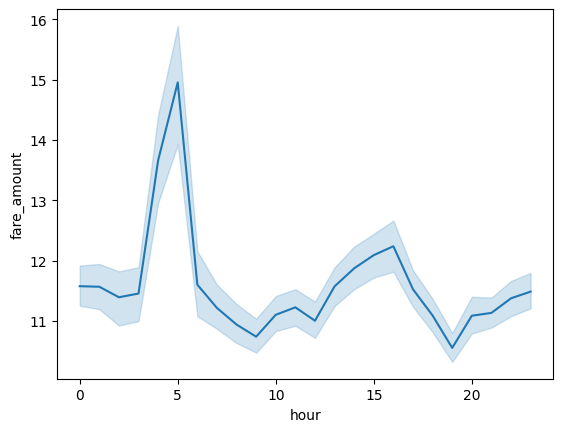

In [17]:
sns.lineplot(x='hour',y='fare_amount',data=df)

<Axes: xlabel='weekday', ylabel='count'>

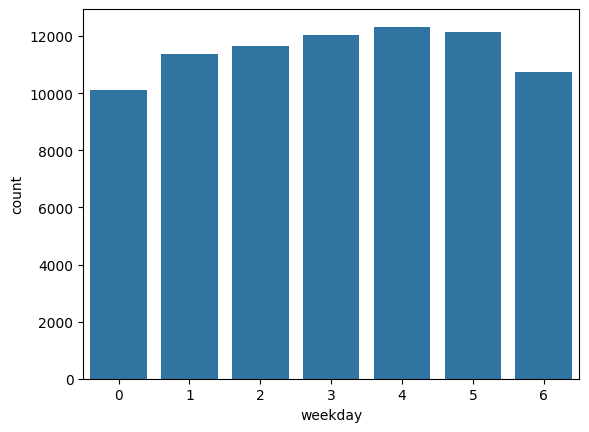

In [18]:
sns.countplot(x='weekday',data=df)

<Axes: xlabel='fare_amount'>

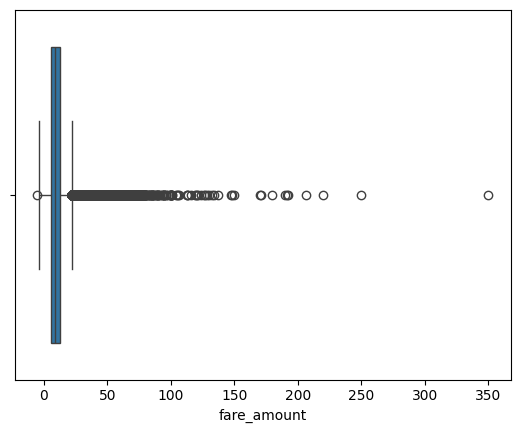

In [19]:
sns.boxplot(x='fare_amount',data=df)

In [20]:
df['fare_amount']=df['fare_amount'].mask(df['fare_amount']>200,200)

<Axes: xlabel='fare_amount'>

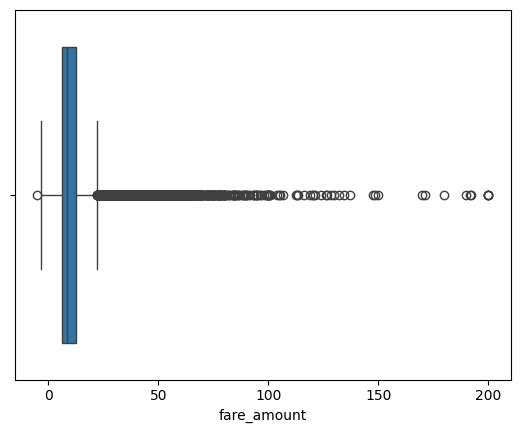

In [21]:
sns.boxplot(x='fare_amount',data=df)

<Axes: >

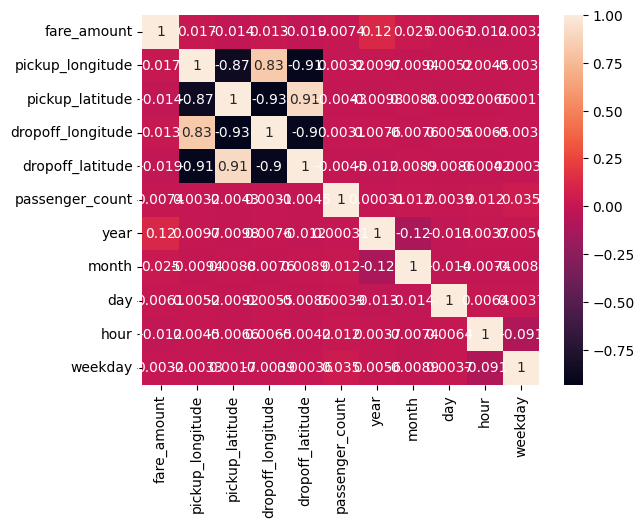

In [22]:
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True)

In [23]:
x=df.drop('fare_amount',axis=1)
y=df['fare_amount']

In [24]:
x.head()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday
0,-73.999817,40.738354,-73.999512,40.723217,1.0,2015,5,7,19,3
1,-73.994355,40.728225,-73.994710,40.750325,1.0,2009,7,17,20,4
2,-74.005043,40.740770,-73.962565,40.772647,1.0,2009,8,24,21,0
3,-73.976124,40.790844,-73.965316,40.803349,3.0,2009,6,26,8,4
4,-73.925023,40.744085,-73.973082,40.761247,5.0,2014,8,28,17,3


In [25]:
y.head()

,fare_amount
0,7.5
1,7.7
2,12.9
3,5.3
4,16.0


In [26]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop('fare_amount',axis=1),df['fare_amount'],test_size=0.2,random_state=42)


In [27]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(x_train,y_train)

LinearRegression()

In [28]:
y_pred_reg=reg.predict(x_test)

In [29]:
y_pred_reg

array([11.65127405, 12.83922348,  9.13956929, ..., 13.22294752,
       10.3720125 , 11.45241172])

In [30]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,y_pred_reg)
mse

89.40734387015964

In [31]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred_reg)
r2

0.01758372439966671

In [32]:
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test,y_pred_reg)
mae

5.913229652084231

In [33]:
from sklearn.metrics import root_mean_squared_error
rmse=np.sqrt(mean_squared_error(y_test,y_pred_reg))
rmse

np.float64(9.455545667499027)

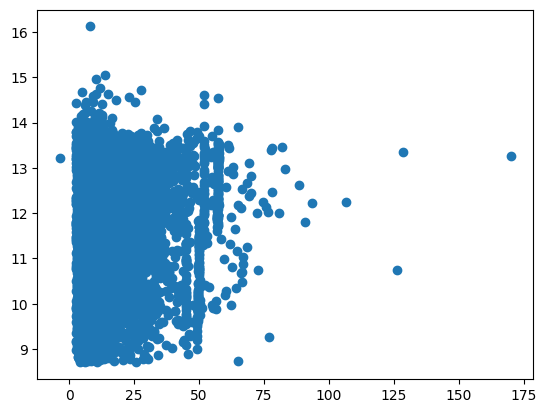

In [34]:
plt.scatter(y_test,y_pred_reg)

In [35]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=20,random_state=42)
rf.fit(x_train,y_train)

RandomForestRegressor(n_estimators=20, random_state=42)

In [36]:
y_pred_rf=rf.predict(x_test)

In [37]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,y_pred_rf)
mse

16.8669054359208

In [38]:
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test,y_pred_rf)
mae

2.0701840504466418

In [39]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred_rf)
r2

0.8146648619455208

In [40]:
from sklearn.metrics import root_mean_squared_error
rmse=np.sqrt(mean_squared_error(y_test,y_pred_rf))
rmse

np.float64(4.106933824146768)

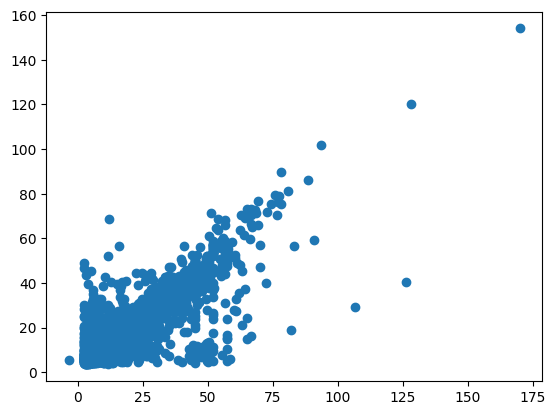

In [41]:
plt.scatter(y_test,y_pred_rf)

In [42]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
alpha=[0.01,0.1,0.5,1,5,10,50,100]
ridge=Ridge()
parameters={'alpha':alpha}
ridge_regressor=GridSearchCV(ridge,parameters,cv=5)
ridge_regressor.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.01, 0.1, 0.5, 1, 5, 10, 50, 100]})

In [43]:
ridge_regressor.best_params_

{'alpha': 100}

In [44]:
y_pred_ridge = ridge_regressor.predict(x_test)

In [45]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,y_pred_ridge)
mse

89.40734128303748

In [46]:
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test,y_pred_ridge)
mae

5.913227585007749

In [47]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred_ridge)
r2


0.017583752827207477

In [48]:
from sklearn.metrics import root_mean_squared_error
rmse=np.sqrt(mean_squared_error(y_test,y_pred_ridge))
rmse

np.float64(9.45554553069454)

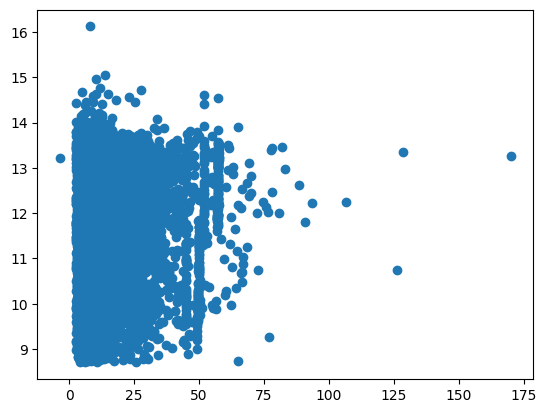

In [49]:
plt.scatter(y_test,y_pred_ridge)